**Оборудование:** Google Colab (бесплатный тариф с GPU). Убедитесь, что вы выбрали среду выполнения с GPU (`Runtime → Change runtime type → T4 GPU`).

# **Практическое занятие: Классификация текстов с помощью трансформеров**

Цель занятия: научиться применять предобученные трансформеры (RuBERT) для классификации русскоязычных текстов, сравнить качество с простыми методами (TF‑IDF + логистическая регрессия), а также познакомиться с генеративными моделями (GPT‑2).

Мы будем использовать датасет **Megnis/ru_sentiment_dataset-50000** – русскоязычные отзывы с метками тональности: 0 – NEUTRAL, 1 – POSITIVE, 2 – NEGATIVE.



In [1]:
%pip install -q transformers datasets accelerate scikit-learn pandas matplotlib seaborn tqdm

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'd:\Users\elise\OneDrive\Рабочий стол\Учёба\Магистратура\2 триместр\Нейронные сети\.venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from datasets import load_dataset
import torch
# transformers - для работы с ресурсом HuggingFace.
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, pipeline
from torch.utils.data import Dataset
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


**1. Загрузка и анализ данных**

Загрузим датасет `Megnis/ru_sentiment_dataset-50000`. Он содержит только `train` split, поэтому мы сами разделим его на train/validation/test в пропорции 70/15/15 со стратификацией по меткам.

In [3]:
dataset = load_dataset('Megnis/ru_sentiment_dataset-50000', split='train')
df = dataset.to_pandas()
print("Распределение классов:")
print(df['sentiment'].value_counts())
print("\nПримеры текстов:")
print(df.head())

Распределение классов:
sentiment
2    16158
0    16054
1    16000
Name: count, dtype: int64

Примеры текстов:
   Unnamed: 0                                               text  sentiment
0       38060  Неплохой отель, есть бассейн и сауна.Очень пор...          0
1       85314  Плохой ортопед Не ходите никогда к ортопеду Ло...          2
2      153299  Отель расположен в 5 минутах ходьбы от кафедра...          1
3       62771  Стиль обслуживания Салон м. Римская. Совершенн...          2
4      167623  Хороший врач Прикреплена по страховке к данной...          1


In [4]:
X = df['text'].values
y = df['sentiment'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 33748
Размер валидационной выборки: 7232
Размер тестовой выборки: 7232


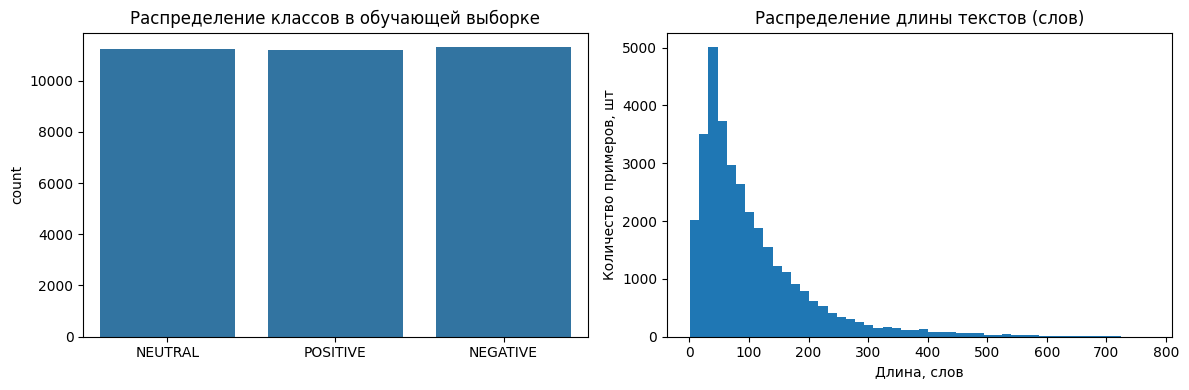

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Распределение классов в обучающей выборке')
axes[0].set_xticklabels(['NEUTRAL', 'POSITIVE', 'NEGATIVE'])

lengths = [len(text.split()) for text in X_train]
axes[1].hist(lengths, bins=50)
axes[1].set_title('Распределение длины текстов (слов)')
axes[1].set_xlabel('Длина, слов')
axes[1].set_ylabel('Количество примеров, шт')

plt.tight_layout()
plt.show()

**2. Baseline: TF‑IDF + логистическая регрессия**

Построим простую модель для сравнения. Векторизуем тексты с помощью TF‑IDF (униграммы + биграммы, максимум 10000 признаков) и обучим логистическую регрессию. Это даст нам нижнюю границу качества.

In [6]:
# В качестве токенов используются слова и их парные комбинации ngram_range=(1,2).
# Максимум слов в словаре на все комментарии будет 10000,  остальные будут отброшены (max_features=10000).

vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_test_pred_lr = lr.predict(X_test_tfidf)
print("Baseline (LogReg + TF-IDF):")
print(classification_report(y_test, y_test_pred_lr, target_names=['NEUTRAL', 'POSITIVE', 'NEGATIVE']))
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")

Baseline (LogReg + TF-IDF):
              precision    recall  f1-score   support

     NEUTRAL       0.67      0.76      0.71      2408
    POSITIVE       0.75      0.64      0.69      2400
    NEGATIVE       0.79      0.79      0.79      2424

    accuracy                           0.73      7232
   macro avg       0.74      0.73      0.73      7232
weighted avg       0.74      0.73      0.73      7232

Accuracy: 0.7327


In [7]:
X_train_tfidf[0]

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 226 stored elements and shape (1, 10000)>

In [8]:
feature_names = vectorizer.get_feature_names_out()
feature_names

array(['00', '00 до', '000', ..., 'ясно', 'ясно что', 'қазақстан'],
      shape=(10000,), dtype=object)

In [9]:
len(feature_names)

10000

**3. Подготовка данных для RuBERT**

Используем русскоязычную модель **DeepPavlov/rubert-base-cased**. Для экономии времени возьмём только 20% обучающих данных (около 7500 примеров), но в полной версии можно использовать всю выборку.

Создадим класс `SentimentDataset` для токенизации и паддинга текстов.

In [10]:
model_name = "DeepPavlov/rubert-base-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# Для ускорения возьмём подвыборку (20% от train)
sample_size = int(0.2 * len(X_train))
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_train_small = X_train[indices]
y_train_small = y_train[indices]

train_dataset = SentimentDataset(X_train_small, y_train_small, tokenizer)
val_dataset = SentimentDataset(X_val, y_val, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

**4. Загрузка модели RuBERT и настройка обучения**

Загрузим предобученную модель с классификационной головой на 3 класса. Используем `Trainer` из библиотеки Transformers. Параметры обучения: 2 эпохи, батч 16, оценка на валидации после каждой эпохи.

In [11]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy='epoch',          # ← замена evaluation_strategy
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='accuracy',
    report_to="none",
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

In [12]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.709682,0.685979,0.727611,0.685979,0.679212
2,0.786807,0.563634,0.741427,0.741230,0.741427,0.741009


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=844, training_loss=0.6844271076799004, metrics={'train_runtime': 146.1543, 'train_samples_per_second': 92.354, 'train_steps_per_second': 5.775, 'total_flos': 887876228123136.0, 'train_loss': 0.6844271076799004, 'epoch': 2.0})

**5. Оценка модели на тестовой выборке и сравнение с baseline**

In [14]:
trainer.callback_handler.callbacks = [cb for cb in trainer.callback_handler.callbacks if cb.__class__.__name__ != 'NotebookProgressCallback']

test_metrics = trainer.evaluate(test_dataset)
print("RuBERT на тестовой выборке:")
print(test_metrics)

# Получим предсказания для теста
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)

print("\nClassification report RuBERT:")
print(classification_report(y_test, y_pred_bert, target_names=['NEUTRAL', 'POSITIVE', 'NEGATIVE']))

print(f"\nAccuracy baseline (TF-IDF): {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Accuracy RuBERT: {test_metrics['eval_accuracy']:.4f}")

RuBERT на тестовой выборке:
{'eval_loss': 0.5569135546684265, 'eval_accuracy': 0.7523506637168141, 'eval_precision': 0.7524428949594969, 'eval_recall': 0.7523506637168141, 'eval_f1': 0.7518618727037892, 'eval_runtime': 17.4024, 'eval_samples_per_second': 415.575, 'eval_steps_per_second': 12.987, 'epoch': 2.0}

Classification report RuBERT:
              precision    recall  f1-score   support

     NEUTRAL       0.70      0.73      0.71      2408
    POSITIVE       0.75      0.69      0.72      2400
    NEGATIVE       0.81      0.83      0.82      2424

    accuracy                           0.75      7232
   macro avg       0.75      0.75      0.75      7232
weighted avg       0.75      0.75      0.75      7232


Accuracy baseline (TF-IDF): 0.7327
Accuracy RuBERT: 0.7524


**6. Визуализация матрицы ошибок**

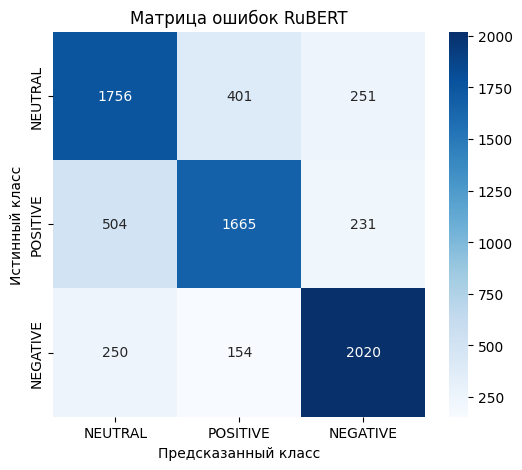

In [15]:
cm = confusion_matrix(y_test, y_pred_bert)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['NEUTRAL', 'POSITIVE', 'NEGATIVE'], yticklabels=['NEUTRAL', 'POSITIVE', 'NEGATIVE'])
plt.title('Матрица ошибок RuBERT')
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.show()

**7. Инференс на новых примерах**

Теперь можно использовать обученную модель для классификации произвольных текстов. Создадим функцию, которая принимает текст и возвращает предсказанную тональность.

In [16]:
def predict_sentiment(text):
    inputs = tokenizer(text, return_tensors='pt', truncation=True, max_length=128).to(device)
    model.to(device)
    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        pred = torch.argmax(outputs.logits, dim=1).item()
    return pred

sample_texts = [
    "Отличный фильм, очень понравился!",
    "Ужасное обслуживание, больше не приду.",
    "Нормально, ничего особенного.",
    """
    О фильме: Картина была представлена в рамках внеконкурсной программы Дикие ночи 47 Московского международного кинофестиваля. На русский язык фильм озвучили Евгений Рыбов и Мария Трындяйкина — «золотые голоса» MTV, «Южного парка», «Клиники» и «Семейки Осборнов».

    Сюжет: Над маленьким американским городком Марлоу нависла угроза — их пытаются поработить вампиры-зомби… из космоса.

    Мнение: Есть жанры фильмов, которые нравятся не всем, например, пародийные комедии — «Очень страшное кино», «Голый пистолет», «Горячие головы» и прочие. Обычно в них упрощенный сюжет, утрированные и глупые персонажи, юмор ниже пояса и пародия на десятки культовых или актуальных фильмов. Также неоднозначны фильмы про мультивселенные и альтернативные реальности под девизом «А что, если…»…

    А что, если смешать вампиров и зомби, и пусть они прилетят из космоса. И всё это будет в «лучших» традициях фильмов ужасов категории «В» 50-х годов, с отсылками и клише классических ужастиков. Я не знаю, как это могло прийти кому-то в голову — сделать нарочито «плохой» фильм с подобным подтекстом, но у режиссера Майкла Стасько, в большинстве своем, задумка сработала.

    И получилась не столько пародия и высмеивание «страшилок без бюджета», сколько дань уважения и почтения забытым и утонувшим в современных спецэффектах малобюджетным хоррорам. Все эти декорации из фольги, неряшливый грим, игрушечные летучие мыши, летающие тарелки на ниточках, бутафорские конечности и литры «кетчупа» — всё это навевает ностальгические чувства с одной стороны и показывает какой огромный шаг сделал кинематограф с другой стороны.

    Для просмотра нужен определенный настрой. Ужастики 50-х годов для многих зрителей ничего уже не говорят, это было очень давно, большинство из них еще не родились, поэтому в полной мере насладиться ностальгией не получится. К тому же намешанный сюжет, местами буксующий, с неравномерными шутками, периодически скатывается к полной несуразице. Но, если отбросить всю аналитику и настроиться на хороший вечер за просмотром пародийного кино, то от данного фильма удастся получить удовольствие.   "
"""
]

for text in sample_texts:
    pred = predict_sentiment(text)
    sentiment = ['NEUTRAL', 'POSITIVE', 'NEGATIVE'][pred]
    print(f"Текст: {text}")
    print(f"Предсказание: {sentiment}\n")

Текст: Отличный фильм, очень понравился!
Предсказание: POSITIVE

Текст: Ужасное обслуживание, больше не приду.
Предсказание: NEGATIVE

Текст: Нормально, ничего особенного.
Предсказание: NEUTRAL

Текст: 
    О фильме: Картина была представлена в рамках внеконкурсной программы Дикие ночи 47 Московского международного кинофестиваля. На русский язык фильм озвучили Евгений Рыбов и Мария Трындяйкина — «золотые голоса» MTV, «Южного парка», «Клиники» и «Семейки Осборнов».

    Сюжет: Над маленьким американским городком Марлоу нависла угроза — их пытаются поработить вампиры-зомби… из космоса.

    Мнение: Есть жанры фильмов, которые нравятся не всем, например, пародийные комедии — «Очень страшное кино», «Голый пистолет», «Горячие головы» и прочие. Обычно в них упрощенный сюжет, утрированные и глупые персонажи, юмор ниже пояса и пародия на десятки культовых или актуальных фильмов. Также неоднозначны фильмы про мультивселенные и альтернативные реальности под девизом «А что, если…»…

    А что, ес

**8. (Опционально) Демонстрация генерации текста с помощью GPT‑2**

Для иллюстрации работы декодерной модели используем предобученную GPT‑2 (маленькую версию) и сгенерируем продолжение текста. Это поможет понять разницу между BERT (понимание) и GPT (генерация).

In [17]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

gpt_model_name = "sberbank-ai/rugpt3small_based_on_gpt2"  # небольшая русскоязычная GPT
gpt_tokenizer = GPT2Tokenizer.from_pretrained(gpt_model_name)
gpt_model = GPT2LMHeadModel.from_pretrained(gpt_model_name)

gpt_tokenizer.pad_token = gpt_tokenizer.eos_token

prompt = "Сегодня я решил попробовать новый ресторан"
inputs = gpt_tokenizer(prompt, return_tensors='pt')

output = gpt_model.generate(
    **inputs,
    max_new_tokens=50,
    do_sample=True,
    temperature=0.8,
    top_p=0.9,
    pad_token_id=gpt_tokenizer.eos_token_id
)

generated_text = gpt_tokenizer.decode(output[0], skip_special_tokens=True)
print("Промпт:", prompt)
print("Сгенерированный текст:", generated_text)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/574 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/720 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/551M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/149 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: sberbank-ai/rugpt3small_based_on_gpt2
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
transformer.h.{0...11}.attn.masked_bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Промпт: Сегодня я решил попробовать новый ресторан
Сгенерированный текст: Сегодня я решил попробовать новый ресторан.  И не жалею.  Очень вкусно, красиво, очень качественно.  Я доволен.  Принесу еще.  Удачи! 
 Хочу сказать огромное спасибо за хороший сервис!  Заказывал столик в ресторане на свадьбу.  Перезвонил


**9. Выводы**

В этом практическом занятии мы:
*   Загрузили и проанализировали датасет русскоязычных отзывов.
*   Построили базовую модель на TF‑IDF и логистической регрессии.
*   Тонко настроили модель RuBERT для классификации тональности.
*   Сравнили качество: трансформеры значительно превосходят простые методы.
*   Попробовали генерировать текст с помощью GPT‑2.

**Важные замечания:**
*   Для ускорения обучения мы использовали только 20% обучающих данных. При использовании всей выборки качество может быть выше.
*   Для русскоязычных задач важно выбирать модели, обученные на русском языке (RuBERT, ruGPT и др.).
*   Трансформеры требуют больше вычислительных ресурсов, но обеспечивают гораздо лучшее качество.

Теперь вы можете применить эти техники к своим данным в рамках финального проекта!

**Задания:**
1. Попробовать большее количество эпох.
2. Попробовать добавить другие отзывы о фильмах или не только о фильмах.
3. Попробовать использовать более объёмный набор данных или свой по интересу или из ВКРМ.

### Берём данные из Кинопоиска

In [18]:
df_new = load_dataset('blinoff/kinopoisk',split='train').to_pandas()
df_new.head()

README.md: 0.00B [00:00, ?B/s]

kinopoisk.jsonl:   0%|          | 0.00/143M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/36591 [00:00<?, ? examples/s]

,part,movie_name,review_id,author,date,title,grade3,grade10,content
0,top250,Блеф (1976),17144,Come Back,2011-09-24,Плакали наши денежки ©,Good,10,"\n""Блеф» — одна из моих самых любимых комедий...."
1,top250,Блеф (1976),17139,Stasiki,2008-03-04,None,Good,0,\nАдриано Челентано продолжает радовать нас св...
2,top250,Блеф (1976),17137,Flashman,2007-03-04,None,Good,10,"\nНесомненно, это один из великих фильмов 80-х..."
3,top250,Блеф (1976),17135,Sergio Tishin,2009-08-17,""" Черное, красное, ерунда это все. Выигрывает ...",Good,0,\nЭта фраза на мой взгляд отражает сюжет несом...
4,top250,Блеф (1976),17151,Фюльгья,2009-08-20,"«Он хотел убежать? Да! Блеф, блеф…»",Neutral,7,"\n- как пела Земфира, скорее всего, по соверше..."


In [19]:
print(df_new['grade3'].value_counts())

grade3
Good       27264
Bad         4751
Neutral     4576
Name: count, dtype: int64


In [21]:
X = df_new['content'].to_list()
y = df_new['grade3'].to_list()

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер валидационной выборки: {len(X_val)}")
print(f"Размер тестовой выборки: {len(X_test)}")

Размер обучающей выборки: 25613
Размер валидационной выборки: 5489
Размер тестовой выборки: 5489


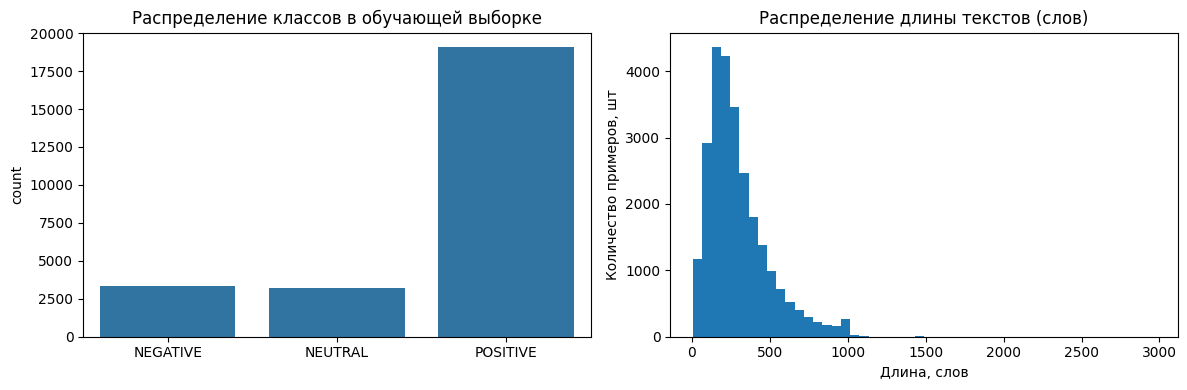

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=y_train, ax=axes[0], order=['Bad', 'Neutral', 'Good'])
axes[0].set_title('Распределение классов в обучающей выборке')

axes[0].set_xticklabels(['NEGATIVE', 'NEUTRAL', 'POSITIVE'])

lengths = [len(text.split()) for text in X_train]
axes[1].hist(lengths, bins=50)
axes[1].set_title('Распределение длины текстов (слов)')
axes[1].set_xlabel('Длина, слов')
axes[1].set_ylabel('Количество примеров, шт')

plt.tight_layout()
plt.show()

In [23]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)

y_test_pred_lr = lr.predict(X_test_tfidf)
print("Baseline (LogReg + TF-IDF):")
print(classification_report(y_test, y_test_pred_lr, target_names=['NEUTRAL', 'POSITIVE', 'NEGATIVE']))
print(f"Accuracy: {accuracy_score(y_test, y_test_pred_lr):.4f}")

Baseline (LogReg + TF-IDF):
              precision    recall  f1-score   support

     NEUTRAL       0.74      0.71      0.73       713
    POSITIVE       0.87      0.97      0.91      4090
    NEGATIVE       0.43      0.16      0.23       686

    accuracy                           0.83      5489
   macro avg       0.68      0.61      0.62      5489
weighted avg       0.80      0.83      0.80      5489

Accuracy: 0.8318


In [24]:
model_name = "DeepPavlov/rubert-base-cased"
#model_name = 'cointegrated/rubert-tiny2'
tokenizer = AutoTokenizer.from_pretrained(model_name)

label_map = {'Bad': 0, 'Neutral': 1, 'Good': 2}

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts
        self.labels = [label_map[label] for label in labels]
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


sample_size = int(len(X_train))
indices = np.random.choice(len(X_train), sample_size, replace=False)
X_train_small = [X_train[i] for i in indices]
y_train_small = [y_train[i] for i in indices]

train_dataset = SentimentDataset(X_train_small, y_train_small, tokenizer)
val_dataset = SentimentDataset(X_val, y_val, tokenizer)
test_dataset = SentimentDataset(X_test, y_test, tokenizer)

In [25]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    ignore_mismatched_sizes=True
)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,             
    learning_rate=2e-5,              
    per_device_train_batch_size=16,   
    per_device_eval_batch_size=16,   
    warmup_steps=300,                
    weight_decay=0.01,
    logging_dir='./logs',
    eval_strategy='epoch',          
    save_strategy='epoch',
    load_best_model_at_end=False,
    report_to="none",
    fp16=torch.cuda.is_available(), 
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted', zero_division=0)
    return {'accuracy': acc, 'precision': precision, 'recall': recall, 'f1': f1}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: DeepPavlov/rubert-base-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you

In [26]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.401300,0.404308,0.850975,0.823511,0.850975,0.816185
2,0.339809,0.359271,0.858080,0.842752,0.858080,0.848556
3,0.253413,0.427226,0.857351,0.844511,0.857351,0.849734


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4803, training_loss=0.3565227739666493, metrics={'train_runtime': 1283.0276, 'train_samples_per_second': 59.889, 'train_steps_per_second': 3.743, 'total_flos': 2.021737190480179e+16, 'train_loss': 0.3565227739666493, 'epoch': 3.0})

In [27]:
trainer.callback_handler.callbacks = [cb for cb in trainer.callback_handler.callbacks if cb.__class__.__name__ != 'NotebookProgressCallback']

test_metrics = trainer.evaluate(test_dataset)
print("RuBERT на тестовой выборке:")
print(test_metrics)

predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=-1)
y_test_int = [label_map[label] for label in y_test]

print("\nClassification report RuBERT:")
print(classification_report(y_test_int, y_pred_bert, target_names=['Bad', 'Neutral', 'Good']))

print(f"\nAccuracy baseline (TF-IDF): {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"Accuracy RuBERT: {test_metrics['eval_accuracy']:.4f}")

RuBERT на тестовой выборке:
{'eval_loss': 0.44652238488197327, 'eval_accuracy': 0.8507924940790672, 'eval_precision': 0.8363253502523569, 'eval_recall': 0.8507924940790672, 'eval_f1': 0.8423329480258845, 'eval_runtime': 30.5208, 'eval_samples_per_second': 179.844, 'eval_steps_per_second': 11.271, 'epoch': 3.0}

Classification report RuBERT:
              precision    recall  f1-score   support

         Bad       0.78      0.77      0.78       713
     Neutral       0.44      0.33      0.38       686
        Good       0.91      0.95      0.93      4090

    accuracy                           0.85      5489
   macro avg       0.71      0.69      0.70      5489
weighted avg       0.84      0.85      0.84      5489


Accuracy baseline (TF-IDF): 0.8318
Accuracy RuBERT: 0.8508


**Заключение:**
1. Новые навыки/умения/знания.
2. Пожелания по содержимому лекционного и практического блокнотов, по способу предоставления материала.
